# CMR Encoding-Matrix Diagnostics
## $\gamma_{fc}$ and $\beta_{enc}$-scale Sweeps

This notebook inspects the **learned association matrices** $M_{FC}$ and $M_{CF}$ that the CMR model builds during the study (encoding) phase.  
We sweep two parameters that directly shape those matrices and plot three targeted readouts:

| Readout | Matrix | What it reveals |
|---|---|---|
| Lag-strength profile | $M_{FC}$ | How strongly each serial-position lag is encoded (contiguity gradient) |
| Lag-strength profile | $M_{CF}$ | How strongly each item is cued by its study-context neighbourhood |
| Forward / backward asymmetry | $M_{FC}$ | Whether forward associations are stronger than backward ones |

---

## Why inspect $M_{FC}$ and $M_{CF}$?

### $M_{FC}$ — drives temporal contiguity during retrieval

In CMR-style retrieval, recalling item $\mathbf{f}_i$ produces an incoming context cue

$$
\mathbf{c}^{\text{raw}}_{\text{in}}
  = M_{FC}\,\mathbf{f}_i,
\qquad
\hat{\mathbf{c}}_{\text{in}}
  = \frac{\mathbf{c}^{\text{raw}}_{\text{in}}}
         {\|\mathbf{c}^{\text{raw}}_{\text{in}}\|}.
$$

The structure of $M_{FC}$ therefore determines **what direction of context** gets reinstated after recalling item $i$, which is exactly what drives:

- **Local contiguity** — $P(|\ell|=1 \mid \text{opportunities})$
- **Large-lag transitions** — $P(|\ell|\ge 4 \mid \text{opportunities})$
- **Directional asymmetry** — $P(\ell=+1 \mid \text{opp.})$ vs $P(\ell=-1 \mid \text{opp.})$

### $M_{CF}$ — drives item accessibility given context

$M_{CF}$ matters most for **which items win the retrieval competition** given the current context cue (i.e., global accessibility / cue → item mapping strength). That makes it the primary determinant of:

- **Recall accuracy** and overall performance level
- **Serial-position curve (SPC)** and **probability of first recall (PFR)** level shifts
- Encoding manipulations like $\gamma_{fc}$ and $\beta_{enc}$-scale that change the association strengths directly

### Why $\eta$ and $\beta_{rec}$ sweeps are excluded here

- **$\eta$ (retrieval noise)** does not alter the encoding matrices at all — it adds
  stochastic perturbation to the activation vector *during* retrieval. Inspecting frozen
  $M_{FC}$ / $M_{CF}$ therefore cannot explain $\eta$'s effects beyond noting that the
  retrieval rule itself differs.
- **$\beta_{rec}$** mainly controls how much the *reinstated* context replaces the current
  context during each retrieval step. It changes retrieval dynamics (cue-alignment
  trajectory), not what was encoded, so frozen matrices are again not the right lens.

---

## 1 · Setup

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")   

# ── Reloadable project modules ──
import importlib
import cmr.diagnostics_encoding as de
import cmr.visualization as viz
import cmr.config as cfg
import cmr.sweep as swp

# Reload modules so edits in cmr/ take effect without restarting kernel
importlib.reload(de)
importlib.reload(viz)
importlib.reload(cfg)
importlib.reload(swp)

# ── Config exports (mirror prior style) ──
N = cfg.N
BASE_PARAMS = cfg.BASE_PARAMS
gamma_fc_grid = cfg.gamma_fc_grid
B_encD_scale_grid = cfg.B_encD_scale_grid
n_sims = cfg.n_sims

# ── Core sweep function ──
sweep_one_param = swp.sweep_one_param

# ── Diagnostics exports ──
_required_de = [
    "sweep_forward_backward_asymmetry",
]

# Bind the diagnostics to use later
sweep_forward_backward_asymmetry = de.sweep_forward_backward_asymmetry

# ── Visualization helpers exports ──
_required_viz = [
    "make_sweep_colors",
    "line_with_colored_points",
    "plot_w_fc_lag_strength_profile_sweep",
    "plot_w_fc_forward_backward_lag_asymmetry_sweep",
    "plot_split_lags"
]

make_sweep_colors = viz.make_sweep_colors
line_with_colored_points = viz.line_with_colored_points
plot_w_fc_lag_strength_profile_sweep = viz.plot_w_fc_lag_strength_profile_sweep
plot_w_fc_forward_backward_lag_asymmetry_sweep = viz.plot_w_fc_forward_backward_lag_asymmetry_sweep
plot_split_lags = viz.plot_split_lags

## 2 · Run the two parameter sweeps

Each call below simulates the full study → recall pipeline at every grid value,
stores the resulting weight matrices, and prints progress.

In [6]:
# ── Sweep 1: γ_fc (learning rate for feature → context associations) ──
sweep_gamma_fc = sweep_one_param(
    param_name="gamma_fc",        # which parameter to vary
    param_grid=gamma_fc_grid,      # list of values to try
    base_params=BASE_PARAMS,       # all other params stay at defaults
    n_sims=n_sims,                 # Monte-Carlo trials per condition
    collect_diagnostics=True,      # save weight matrices & recall data
    recency_k=3,                   # track the 3 most-recent items for PFR
)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


In [7]:
# ── Sweep 2: β_enc scale (global multiplier on all encoding drift rates) ──
sweep_B_enc_scale = sweep_one_param(
    param_name="B_encD_scale",
    param_grid=B_encD_scale_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


---
## 3 · $\gamma_{fc}$ sweep results

$\gamma_{fc}$ is the Hebbian learning rate that scales how much each
new item-context association is added to $M_{FC}$ during encoding.
Larger values → stronger (and potentially more differentiated) associations.

### 3.1 · Lag-strength profile of $M_{FC}$

Each curve is the mean absolute weight at every serial-position lag,
coloured by the $\gamma_{fc}$ value that produced it.
A peaked profile at lag 0 / ±1 indicates strong *contiguity* encoding.

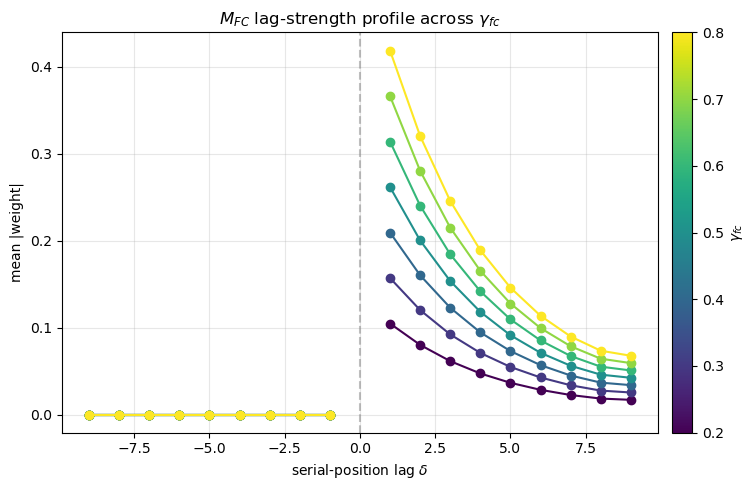

In [8]:
plot_w_fc_lag_strength_profile_sweep(
    sweep_gamma_fc,
    gamma_fc_grid,
    param_name=r"$\gamma_{fc}$",
    matrix_key="net_w_fc",          # inspect M_FC
)

### 3.2 · Lag-strength profile of $M_{CF}$

Same readout but for the context → feature matrix.  Changes here
reflect shifts in *which items can be recalled* given a context cue.

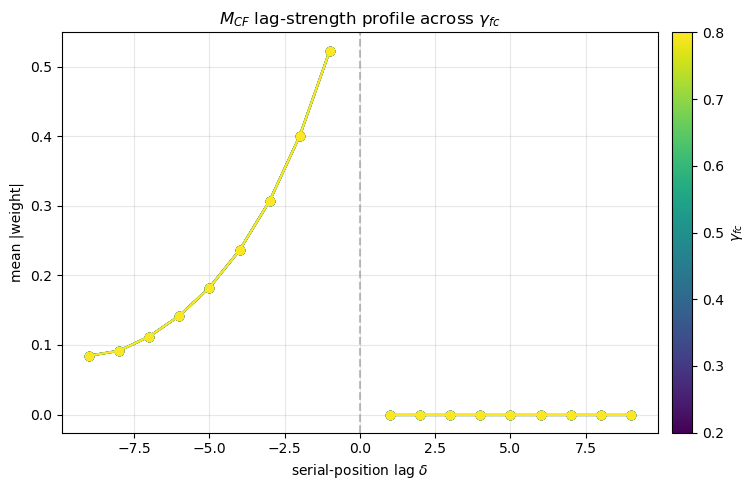

In [9]:
plot_w_fc_lag_strength_profile_sweep(
    sweep_gamma_fc,
    gamma_fc_grid,
    param_name=r"$\gamma_{fc}$",
    matrix_key="net_w_cf",          # inspect M_CF this time
)

### 3.3 · Forward / backward asymmetry of $M_{FC}$

Positive asymmetry = the mean weight at lag +1 exceeds the mean weight at lag −1,
meaning the matrix preferentially encodes *forward* temporal associations.

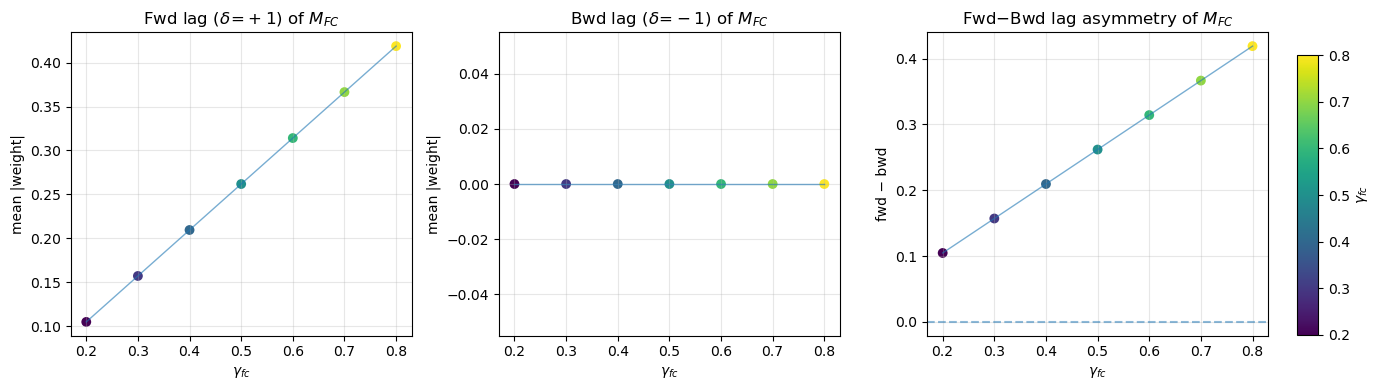

In [10]:
plot_w_fc_forward_backward_lag_asymmetry_sweep(
    sweep_gamma_fc,
    gamma_fc_grid,
    param_name=r"$\gamma_{fc}$",
    matrix_key="net_w_fc",
)

---
## 4 · $\beta_{enc}$-scale sweep results

The $\beta_{enc}$-scale multiplier uniformly rescales all encoding
drift-rate parameters.  A larger scale means context drifts faster
between study items, making neighbouring contexts more distinct and
changing the association landscape in both $M_{FC}$ and $M_{CF}$.

### 4.1 · Lag-strength profile of $M_{FC}$

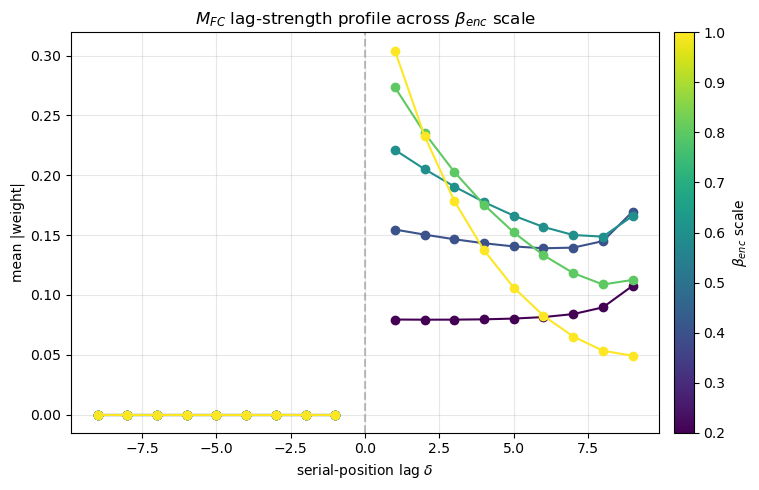

In [11]:
plot_w_fc_lag_strength_profile_sweep(
    sweep_B_enc_scale,
    B_encD_scale_grid,
    param_name=r"$\beta_{enc}$ scale",
    matrix_key="net_w_fc",
)

### 4.2 · Lag-strength profile of $M_{CF}$

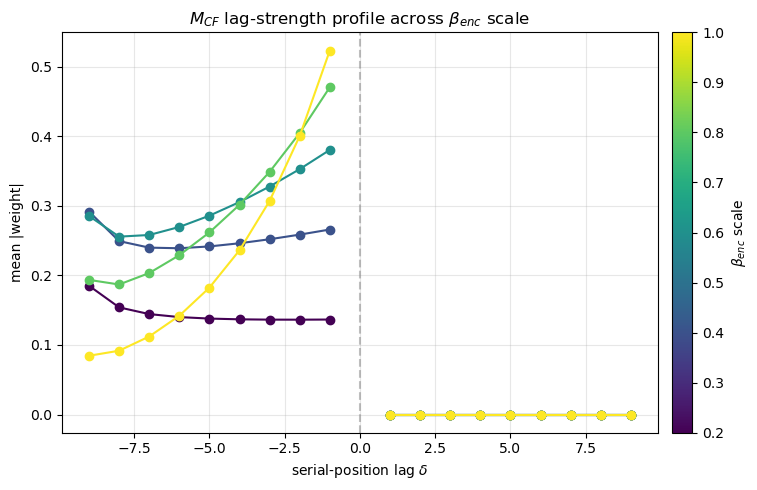

In [12]:
plot_w_fc_lag_strength_profile_sweep(
    sweep_B_enc_scale,
    B_encD_scale_grid,
    param_name=r"$\beta_{enc}$ scale",
    matrix_key="net_w_cf",
)

### 4.3 · Forward / backward asymmetry of $M_{FC}$

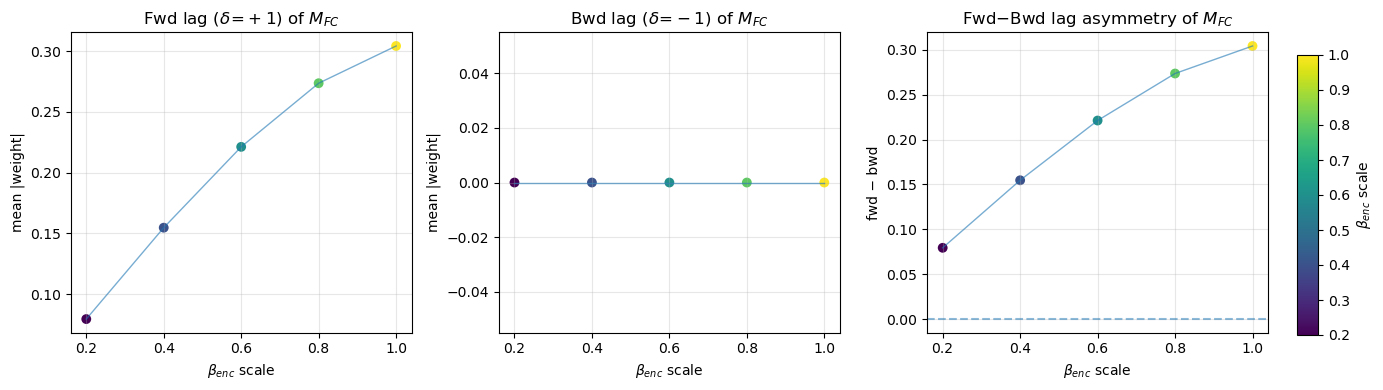

In [13]:
plot_w_fc_forward_backward_lag_asymmetry_sweep(
    sweep_B_enc_scale,
    B_encD_scale_grid,
    param_name=r"$\beta_{enc}$ scale",
    matrix_key="net_w_fc",
)

---
## Cross-parameter comparison

| | $\gamma_{fc}$ | $\beta_{enc}$ scale |
|---|---|---|
| **Row 0** | $M_{FC}$ lag profile | $M_{FC}$ lag profile |
| **Row 1** | $M_{CF}$ lag profile | $M_{CF}$ lag profile |
| **Row 2** | $M_{FC}$ fwd / bwd asymmetry | $M_{FC}$ fwd / bwd asymmetry |

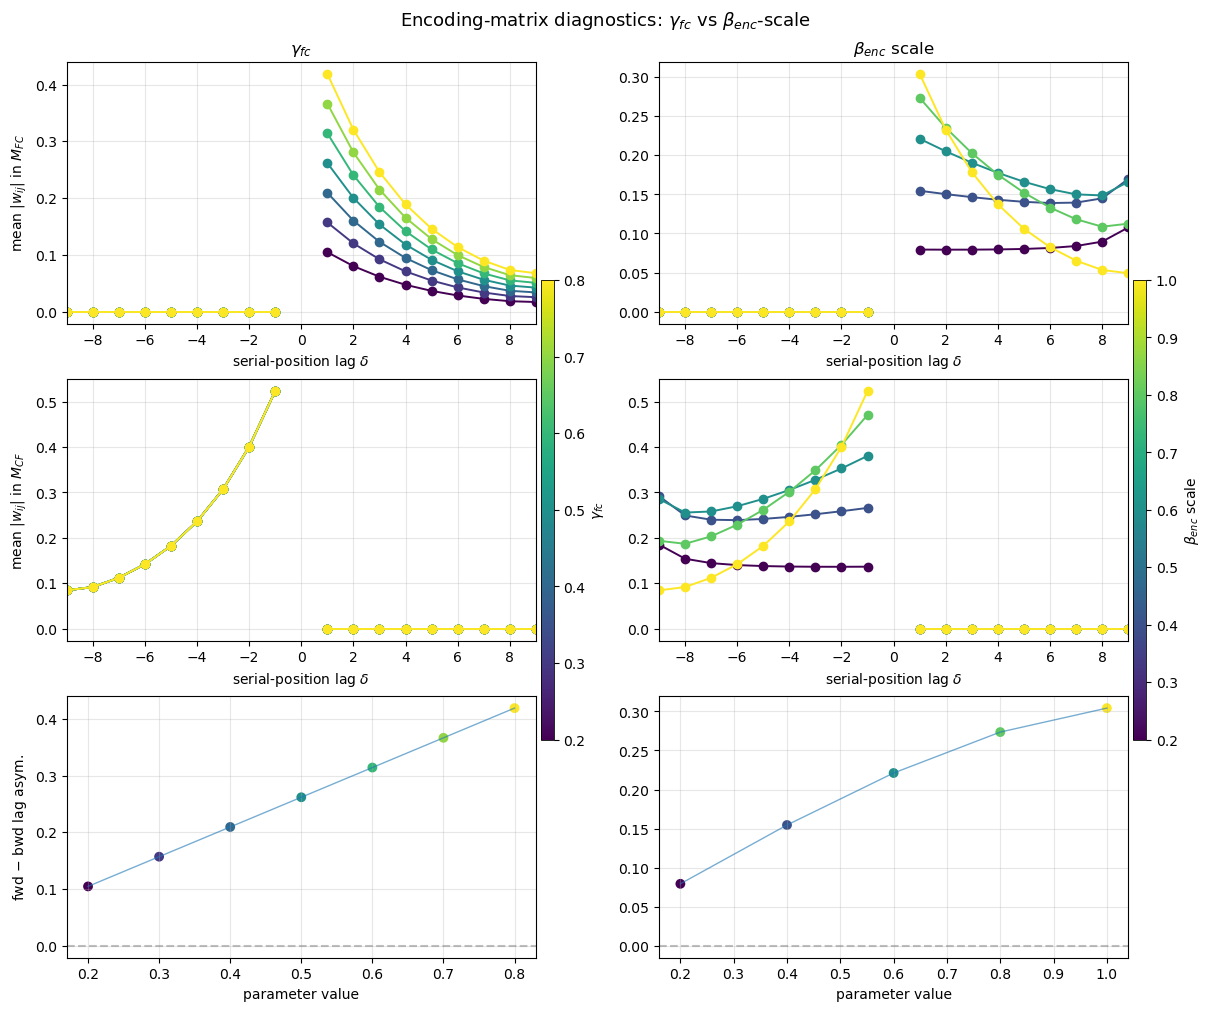

In [28]:

sweeps = [
    (sweep_gamma_fc,    gamma_fc_grid,      r"$\gamma_{fc}$"),
    (sweep_B_enc_scale, B_encD_scale_grid,  r"$\beta_{enc}$ scale"),
]

fig, axs = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

for col, (sweep, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid)

    # ── Row 0: M_FC lag-strength profile ──
    lags, profiles = sweep_lag_strength_profile(sweep, grid, matrix_key="net_w_fc")
    ax = axs[0, col]
    for k in range(len(grid)):
        plot_split_lags(ax, lags, profiles[k], color=colors[k], linewidth=1.4)
    ax.set_xlim(lags[0], lags[-1])
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"mean $|w_{ij}|$ in $M_{FC}$")
    ax.set_xlabel(r"serial-position lag $\delta$")

    # ── Row 1: M_CF lag-strength profile ──
    lags_cf, profiles_cf = sweep_lag_strength_profile(sweep, grid, matrix_key="net_w_cf")
    ax = axs[1, col]
    for k in range(len(grid)):
        plot_split_lags(ax, lags_cf, profiles_cf[k], color=colors[k], linewidth=1.4)
    ax.set_xlim(lags_cf[0], lags_cf[-1])
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"mean $|w_{ij}|$ in $M_{CF}$")
    ax.set_xlabel(r"serial-position lag $\delta$")

    # ── Row 2: M_FC forward − backward asymmetry ──
    fwd, bwd, asym = sweep_forward_backward_asymmetry(sweep, grid, matrix_key="net_w_fc")
    ax = axs[2, col]
    line_with_colored_points(ax, grid, asym, colors)
    ax.axhline(0, ls="--", color="gray", alpha=0.5)
    ax.grid(alpha=0.3)
    if col == 0:
        ax.set_ylabel(r"fwd $-$ bwd lag asym.")
    ax.set_xlabel("parameter value")

    # ── Column title + thinner colorbar ──
    axs[0, col].set_title(label, fontsize=12)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axs[:, col].tolist(),
        pad=0.01,        # tighter to axes
        shrink=0.62,
        fraction=0.028,  # thinner bar
        aspect=35,       # higher aspect => thinner-looking bar
        label=label
    )
    cbar.outline.set_linewidth(0.6)

fig.suptitle(
    "Encoding-matrix diagnostics: " + r"$\gamma_{fc}$ vs $\beta_{enc}$-scale",
    fontsize=13
)
plt.show()